# **DIC Project - personalised_general_drug_prescriptions - Phase 1** 
 ------------------------------------------------------------------

 # **`Task 1`** :

### **`Title : Personalised General Drug Prescriptions`**
#### **Problem Domain** : Healthcare and Personalised Medicine
####  **Problem Statement** :<div style="font-weight: 300; padding-top: 5px;"> The traditional approach to drug prescriptions often adheres to a standard approach, which presents significant  challenges. In this ‘one-size-fits-all’ model of prescribing, there are many problems. Drug reactions are rampant, patients are given ineffective treatment plans, and costs in the medical system balloon. For example, almost 10 per cent of patients who are hospitalised suffer ill effects from errors in prescribing medications. This clearly points to the need for a more personalised kind of medicine prescriptions. </div>
#### **Objectives** :<div style="font-weight: 300; padding-top: 5px;"> The objective of this project is, to utilize insights derived from datasets by web-scraping unstructured data from Drugs.com website and converting it into structured data. We are going to work on two datasets, one is the Symptoms dataset, used to train the ML model to diagnose the disease of the patient by inputting the symptoms that the patient have. Our second dataset is Treatment Options dataset, where we recommend the best treatment medicine available in the market based on the disease predicted. We are trying to develop an app that will suggest personalised medications for specific diseases by the user's symptoms. </div>

#### **Potential**: <div style="font-weight: 300; padding-top: 5px;"> Patients will be able to mange their health more effectively by avoiding unnecessary visits to doctor. Our main objective is to decrease the healthcare costs and improve patient outcomes. By incorporating machine learning models and data from trusted medical resources like Drugs.com, this system can reduce any potential risks in prescribing incorrect or ineffective medications. Patients will be subjected to differential treatments in order to eliminate certain conditions and lessen adverse reactions, hence vastly improving the recovery rates. This project makes healthcare effective since it saves useless visits to the hospital,saves the doctor's time, and cuts down on general health care costs. In the long run, this individualistic approach can make health care more available, more accurate, and with great potential for improvement regarding patient satisfaction and public health in its totality.<div>

 # **`Task 2`** :

# **Questions :** 

### Team Member 1 : `Shreyas Bellary Manjunath`
#### Q1) Drugs with higher dosages, which come under abusive controlled substances (CSA), tend to have lower ratings, and more adverse effects (higher reviews) especially when alcohol interaction is present.
#### Q2) Drugs that are marketed under multiple brand names tend to receive a lower total number of reviews compared to those marketed under a single brand name.

### Team Member 2 : `Shishir Hebbar`
#### Q3) Is there a significant correlation between the dosage of drugs given for pain and their effectiveness in treating the pain?
#### Q4) How does the frequency of a drug's prescription relate to its perceived effectiveness (rating)?


### Team Member 3 : `Janhavi Gubbala`
#### Q5) How do specific symptoms (e.g., fever, cough, difficulty breathing) combined with health indicators (e.g., blood pressure, cholesterol level) affect the likelihood of patients being diagnosed with severe respiratory conditions such as asthma or influenza?
#### Q6) Are older age groups more likely to have higher cholesterol levels compared to younger age groups?

### Team Member 4 : `Ruthvik Vasantha Kumar`
#### Q7) What is the impact of pregnancy safety categories on the prescription patterns of drugs for women of childbearing age?
#### Q8) What is the correlation between drug activity levels (percentage of patients who experience effectiveness) and prescription status (Rx vs. OTC)?

 # **`Task 3`** :

#### Data-Retrieval includes retrieval of 2 datasets (symptoms.csv, treatment_options.csv) for further cleaning and EDA purposes. In the future phases, we use the cleaned datasets to train ML models and the data insights drawn to fine tune the model for better prediction and accuracy. We performed the following steps to retrieve the datasets: 

#### **symptoms.csv :** 
<ul>
  <li>
    <div style="font-weight: 300; font-size: 17px;">We found the patient profile dataset on Kaggle (<a href="https://www.kaggle.com/datasets/rigatoni30/patient-profile-disease-symptoms" target="_blank">Patient Profile Disease Symptoms Dataset</a>)</div>
  </li>
  <li>
    <div style="font-weight: 300; font-size: 17px;">We retrieved the dataset and stored it on Google Drive for easier access and safe storage.</div>
  </li>
  <li>
    <div style="font-weight: 300; font-size: 17px;">Using the URL of the file location, we are able to read the dataset directly from the URL into our environment.</div>
  </li>
</ul>


#### **treatment_options.csv :** 
<ul>
  <li>
    <div style="font-weight: 300; font-size: 17px;">
      A target website (Drugs.com) was found online with the most recent drug data, which we were able to scrape using 
      the <code>scrape.py</code> file (found on our private GitHub page - 
      <a href="https://github.com/Shreyas-bellary/personalised-general-drug-prescriptions" target="_blank">GitHub Repository</a>). 
      This process converted the unstructured data to a structured dataset, resulting in 4000+ data points and 12 attribute values for the drug.
    </div>
  </li>
  <li>
    <div style="font-weight: 300; font-size: 17px;">
      After the successful run, we obtained a .csv file, which we read directly using pandas <code>read_csv</code> function to a DataFrame.
    </div>
  </li>
</ul>

#### The webscraping included mainly 3 parts, 

- #### <div style="font-weight: 300"> First we scraped all the diseases and thier respective drug links from the site (https://www.drugs.com/medical_conditions.html). This was achieved by the following function :</div>


In [11]:
# Function to scrape all the diseases and its treatment option links
def get_treatment_options(url): 
    response = get_html(url)
    soup = BeautifulSoup(response, 'html.parser')
    head = soup.head
    if head:
        head.extract()
    treatment_options = soup.find_all('ul', class_="ddc-list-column-4")
    new_soup = BeautifulSoup(str(treatment_options), 'html.parser')
    disease_list = []
    disease_links = []
    all_diseases = new_soup.find_all('a')
    for disease in all_diseases:
        disease_text = disease.get_text(strip=True)
        if disease_text == "Weight Loss":
            disease_list.append("Obesity")
            disease_links.append("https://www.drugs.com" + disease['href'])
        elif disease_text == "Incontinence":
            disease_list.append("Urinary Incontinence")
            disease_links.append("https://www.drugs.com" + disease['href'])
        elif disease_text != "Mental Health":
            disease_list.append(disease_text)
            disease_links.append("https://www.drugs.com" + disease['href'])   
    disease_list.append("Fever")
    disease_links.append("https://www.drugs.com/condition/fever.html")
    return disease_list, disease_links

- #### <div style="font-weight: 300"> Next, we scraped each of the retrieved disease links which contained multiple drugs for the treatment of that respective disease and 9 different attributes for each drug. Also, we retieve each of the link to the respective drug's webpage for further detailed scraping. This was achieved by the following function :</div>

In [13]:
# Function to scrape data for each disease treatment drug link
def scrape_drug_info(link, disease):
    response = get_html(link + "?page_all=1")
    soup = BeautifulSoup(response, 'html.parser')
    medicines = soup.find_all(class_="ddc-table-row-medication data-table-row")
    results = []
    for medicine in medicines:
        new_soup = BeautifulSoup(str(medicine), 'html.parser')
        drug_name = new_soup.find('a', class_="ddc-text-wordbreak").get_text(strip=True)
        dlink = "https://www.drugs.com" + new_soup.find('a', class_="ddc-text-wordbreak")['href']
        rate = new_soup.find('td', class_="ddc-text-center").get_text(strip=True)
        rate = None if rate == "Rate" else rate
        rev = new_soup.find('a', class_="ddc-text-nowrap").get_text(strip=True).split()[0]
        rev = None if rev == "Add" else rev
        activity_div = new_soup.find(class_="ddc-rating-bar")
        act = re.search(r'(\d+)%', activity_div['aria-label']).group(1) if activity_div else None
        attributes = new_soup.find_all('td', class_="ddc-text-center")
        prescription = attributes[1].get_text(strip=True)
        preg = attributes[2].get_text(strip=True)
        csa = attributes[3].get_text(strip=True)
        alcohol = attributes[4].get_text(strip=True)
        brand_name, dosage, allergy = get_detailed_drug_info(dlink)
        results.append([drug_name, brand_name, dosage, rate, rev, act, prescription, preg, csa, alcohol, allergy, disease]) # 9 unique attributes
    return results

- #### <div style="font-weight: 300"> Next, we visit webpages of each drug scraped from the previous section to retrieve further 3 attributes out of the drug. This was achieved by the following function :</div>

In [15]:
# Function to scrape detailed drug info for each link from previous section
def get_detailed_drug_info(url):
    Bname = []
    mg = []
    allergy = []
    response = get_html(url)
    if response is None:
        return Bname, mg, allergy
    soup = BeautifulSoup(response, 'html.parser')
    content = soup.find("p", class_="drug-subtitle")  
    if content:
        content_str = content.get_text(separator=" ", strip=True)
        start_pos = content_str.find("Brand names:")
        if start_pos == -1:
            start_pos = content_str.find("Brand name:")
        # Stop extraction at "show all" if present
        end_pos_show_all = content_str.find("... show all")
        # Handle both "Dosage form" and "Dosage forms"
        end_pos_dosage_form = content_str.find("Dosage form:")
        if end_pos_dosage_form == -1:
            end_pos_dosage_form = content_str.find("Dosage forms:")
        end_pos_drug_class = content_str.find("Drug class:")
        # Determine the valid end position
        end_pos = min(end_pos_dosage_form, end_pos_drug_class) if end_pos_dosage_form != -1 and end_pos_drug_class != -1 else max(end_pos_dosage_form, end_pos_drug_class)
        if end_pos == -1:
            end_pos = len(content_str)
        # If "show all" is found, limit text to just before "show all"
        if end_pos_show_all != -1 and end_pos_show_all < end_pos:
            end_pos = end_pos_show_all
        if start_pos != -1:
            brand_names_section = content_str[start_pos:end_pos].strip()
            brand_names_only = brand_names_section.split(":", 1)[1].strip()
            brand_names_only = brand_names_only.replace(',', ';')
            Bname.append(brand_names_only)
        else:
            Bname.append(None)
    else:
        Bname.append(None)

    sidebox = soup.find('div', class_='ddc-sidebox ddc-sidebox-drug-image')
    if sidebox:
        figcaption = sidebox.find('figcaption')
        mg_value = re.search(r'\d+ mg', figcaption.text)
        mg.append(mg_value.group() if mg_value else None)
    else:
        mg.append(None)
    target_paragraph = soup.find("h2", id="before-taking", string="Before taking this medicine")
    if target_paragraph:
        ul_element = target_paragraph.find_next("ul")
        new_soup = BeautifulSoup(str(ul_element), 'html.parser')
        li_elements = ul_element.find_all('li')
        if li_elements:
                for ele in li_elements:
                    cleaned_text = ele.get_text(strip=True)           
                    # Split based on " or " and " or"
                    cleaned_text = cleaned_text.replace(';', '')
                    cleaned_text = cleaned_text.replace('.', '')
                    # Remove 'or' at the end of the sentence if it exists
                    cleaned_text = cleaned_text.rstrip(' or')
                    allergy.append(cleaned_text)
        else:
            allergy.append(None)
    else:
        allergy.append(None)
    return Bname, mg, allergy # 3 unique attributes

- #### <div style="font-weight: 300"> Thus, obtaining 13 attributes in total for the dataset with 4000+ datapoints. The scraping also uses concurrent thread running mechanism to scrape at a faster pace. This is possible by creating batches and dividing the scraping work among 5 workers. In the end, we write the whole data to a .csv file and store it onto the machine.</div>

 # **`Task 4`** :

In [98]:
# Import the necassary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the dataset scraped from Drugs.com containting 4000+ data points 

In [20]:
!pip install gdown 
import gdown
file_id = '1FGecRWNghOseUt1sT_iH6elwR-8_9JSB'
url = f'https://drive.google.com/uc?id={file_id}'

output = 'your_file.csv'
gdown.download(url, output, quiet=False)

# Now read the file into a pandas DataFrame
df = pd.read_csv(output)
df

,drug_name,brand_name,dosage,rating,review,activity,prescription,preg,csa,alcohol,allergy,disease_list
0,Aricept,['Aricept; Aricept ODT'],['5 mg'],5.0,34.0,100,Rx,C,N,NaN,"['a heart rhythm disorde', 'a history of stoma...",Alzheimer's
1,donepezil,['Aricept ; Aricept ODT'],['5 mg'],5.0,77.0,100,Rx,C,N,NaN,"['a heart rhythm disorder such as ""sick sinus ...",Alzheimer's
2,memantine,['Namenda'],['10 mg'],5.0,64.0,100,Rx,B,N,NaN,[None],Alzheimer's
3,Namenda,['Namenda; Namenda XR'],['5 mg'],5.2,26.0,100,Rx,B,N,NaN,"['have or have had seizures or epilepsy', 'hav...",Alzheimer's
4,Leqembi,[None],['200 mg'],NaN,NaN,31,Rx,NaN,N,NaN,[None],Alzheimer's
...,...,...,...,...,...,...,...,...,...,...,...,...
4347,Back & Body Extra Strength,['Back & Body Extra Strength; Bayer Back & Bod...,[None],NaN,NaN,0,OTC,N,N,X,[None],Fever
4348,BC Arthritis,['Alka-Seltzer Hangover Relief ; Alka-Seltzer ...,[None],NaN,NaN,0,OTC,N,N,X,['an allergy to an NSAID (nonsteroidal anti-in...,Fever
4349,Cope,['Alka-Seltzer Hangover Relief ; Alka-Seltzer ...,[None],NaN,NaN,0,OTC,N,N,X,['an allergy to an NSAID (nonsteroidal anti-in...,Fever
4350,P-A-C,['Back & Body Extra Strength ; Bayer Back & Bo...,[None],NaN,NaN,0,OTC,N,N,X,[None],Fever


In [21]:
df.info()
#print(len(set(df['csa'].to_list())),set(df['csa'].to_list()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4352 entries, 0 to 4351
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   drug_name     4352 non-null   object 
 1   brand_name    4352 non-null   object 
 2   dosage        4352 non-null   object 
 3   rating        2211 non-null   float64
 4   review        2211 non-null   float64
 5   activity      4352 non-null   int64  
 6   prescription  4351 non-null   object 
 7   preg          4021 non-null   object 
 8   csa           4352 non-null   object 
 9   alcohol       2227 non-null   object 
 10  allergy       4352 non-null   object 
 11  disease_list  4352 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 408.1+ KB


## Data cleaning involve the following steps : 

#### **1.** Clean the allergy, brand_name and dosage columns by removing the list notation and extra string (like mg), considering just the values of the attributes. This is achieved by stripping the unnecassary characters and string out of the text using `regex` and `strip()` function to replace.

In [24]:
df['brand_name'] = df['brand_name'].replace(r"[\[\]']", '', regex=True).str.strip() # regex searching for ['....'] pattern to remove 
df['dosage'] = df['dosage'].replace(r"[\[\]'\s*mg]", '', regex=True).str.strip() # regex searching for ['.... mg'] pattern to remove
df['allergy'] = df['allergy'].replace(r"[\[\]]", '', regex=True).str.strip() # regex searching for [...] pattern to strip
df.rename(columns={'dosage': 'dosage_mg'}, inplace=True) # renaming the column name
df.head()

,drug_name,brand_name,dosage_mg,rating,review,activity,prescription,preg,csa,alcohol,allergy,disease_list
0,Aricept,Aricept; Aricept ODT,5,5.0,34.0,100,Rx,C,N,NaN,"'a heart rhythm disorde', 'a history of stomac...",Alzheimer's
1,donepezil,Aricept ; Aricept ODT,5,5.0,77.0,100,Rx,C,N,NaN,"'a heart rhythm disorder such as ""sick sinus s...",Alzheimer's
2,memantine,Namenda,10,5.0,64.0,100,Rx,B,N,NaN,None,Alzheimer's
3,Namenda,Namenda; Namenda XR,5,5.2,26.0,100,Rx,B,N,NaN,"'have or have had seizures or epilepsy', 'have...",Alzheimer's
4,Leqembi,None,200,NaN,NaN,31,Rx,NaN,N,NaN,None,Alzheimer's


#### **2.** Make the None valued cells (which was obtained during scraping) to NaN values for easier data cleaning and filling process using similar process. And convert the datatypes of activity and dosage to float type for easier data maintainability.

In [26]:
df['brand_name'] = df['brand_name'].replace(r"None",np.nan, regex=True).str.strip() # Search for None values and strips it off
df['dosage_mg'] = df['dosage_mg'].replace(r"None",np.nan, regex=True).str.strip()
df['activity'] = df['activity'].astype(float) # Converts to float value
df['dosage_mg'] = df['dosage_mg'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4352 entries, 0 to 4351
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   drug_name     4352 non-null   object 
 1   brand_name    3313 non-null   object 
 2   dosage_mg     2054 non-null   float64
 3   rating        2211 non-null   float64
 4   review        2211 non-null   float64
 5   activity      4352 non-null   float64
 6   prescription  4351 non-null   object 
 7   preg          4021 non-null   object 
 8   csa           4352 non-null   object 
 9   alcohol       2227 non-null   object 
 10  allergy       4352 non-null   object 
 11  disease_list  4352 non-null   object 
dtypes: float64(4), object(8)
memory usage: 408.1+ KB


#### **3.** Fill the rows with NaN with respective values for easier visualization and non-empty values. This can be achieved with the help of `fillna()` function of pandas.

In [28]:
# fills the attributes of the drug with its respective fill value if NaN value found
df.fillna({'dosage_mg': 0,'rating': 0, 'review': 0, 'preg': 'unknown', 'csa': 'unknown', 'prescription': 'unknown', 'brand_name': 'common', 'alcohol': 'N'}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4352 entries, 0 to 4351
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   drug_name     4352 non-null   object 
 1   brand_name    4352 non-null   object 
 2   dosage_mg     4352 non-null   float64
 3   rating        4352 non-null   float64
 4   review        4352 non-null   float64
 5   activity      4352 non-null   float64
 6   prescription  4352 non-null   object 
 7   preg          4352 non-null   object 
 8   csa           4352 non-null   object 
 9   alcohol       4352 non-null   object 
 10  allergy       4352 non-null   object 
 11  disease_list  4352 non-null   object 
dtypes: float64(4), object(8)
memory usage: 408.1+ KB


#### **4.** Check if any duplicates are present in the dataset and drop if present using `duplicated()` function of pandas to check any duplicates. And those duplicates can be dropped further.

In [30]:
duplicate_rows = df[df.duplicated()]
print("Number of duplicates present in data :", len(duplicate_rows)) # check the number of duplicates
df.drop_duplicates(inplace=True) # drops the duplicates if present

Number of duplicates present in data : 0


#### **5.** We plot boxplots for all the columns with numeric data type to see whether outliers are present in the data.

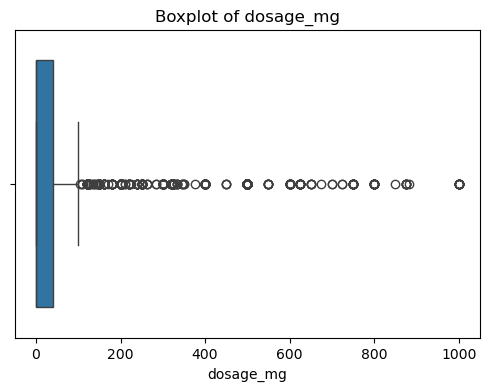

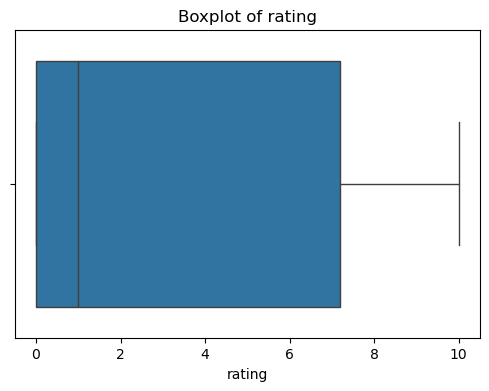

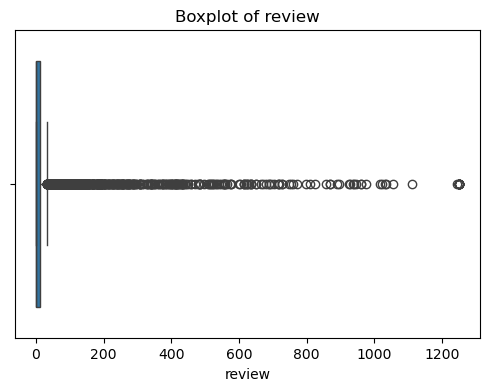

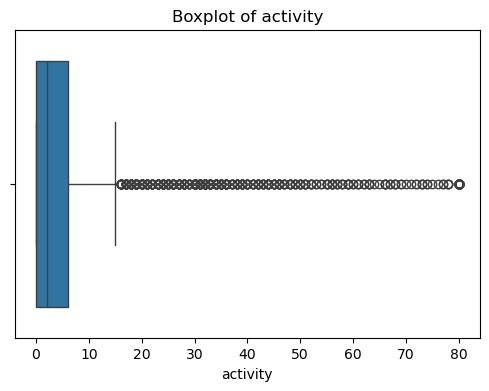

In [102]:
df2 = df # use another dataframe to store the results and let the original frame be intact
numerical_cols = ['dosage_mg', 'rating', 'review', 'activity']  # Numerical columns
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df2[col])
    plt.title(f'Boxplot of {col}') 
    plt.show() # Plot to show outliers: Boxplot used here


#### It is seen from the above plots that 'dosage_mg', 'review', and 'activity' have outliers. However, for the column 'dosage_mg', we do not remove the outliers as this might affect the quality of data later. The higher dosages which look like outliers might actually be true dosages for the given drug. This will come in handy for visualization purposes later. We remove the outliers for 'review' and 'activity' based on a threshold value.

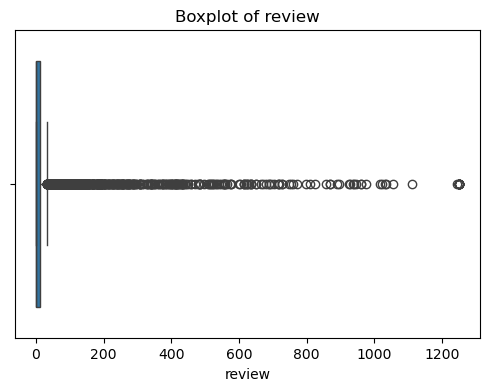

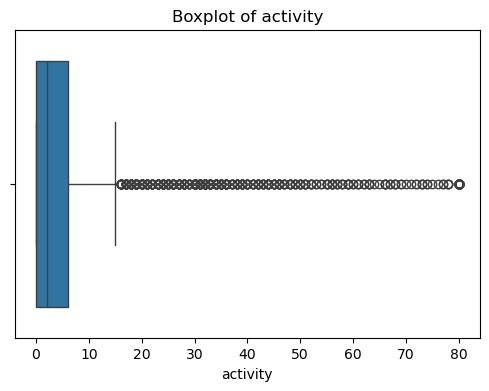

In [79]:
review_threshold = 1250 # As seen in the graph above, outliers are mainly present after 1250
activity_threshold = 80 # As seen in the graph above, outliers are mainly present after 80
df3 = df2 # We take a copy of df2 and store it in df3, this is done to maintain a copy of the original data in case bias is introduced.
df3['review'] = df3['review'].clip(upper=review_threshold)  #This keeps the upper limit of the data to 1250 and anything above that is reduced back to 1250
df3['activity'] = df3['activity'].clip(upper=activity_threshold) #This keeps the upper limit of the data to 80 and anything above that is reduced back to 80
df3

numerical_cols = ['review', 'activity']  # Numerical columns
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df3[col])
    plt.title(f'Boxplot of {col}') 
    plt.show() # Plot to show outliers: Boxplot used here

#### **6.** Convert all object or string type attributes to lower to maintain uniformity in the data using the `lower()` function. This is achieved by finding all the object type columns and applying the lower function to the entire columns.

In [100]:
string_columns = df2.select_dtypes(include=['object']).columns
df2[string_columns] = df2[string_columns].apply(lambda x: x.str.lower())
df2

,drug_name,brand_name,dosage_mg,rating,review,activity,prescription,preg,csa,alcohol,allergy,disease_list,allergy_cleaned,disease_list_cleaned
0,aricept,aricept; aricept odt,5.0,5.0,34.0,80.0,rx,c,n,n,"'a heart rhythm disorde', 'a history of stomac...",alzheimer's,"heart rhythm disorder , history stomach ulcer ...",alzheimers
1,donepezil,aricept ; aricept odt,5.0,5.0,77.0,80.0,rx,c,n,n,"'a heart rhythm disorder such as ""sick sinus s...",alzheimer's,heart rhythm disorder sick sinus syndrome slow...,alzheimers
2,memantine,namenda,10.0,5.0,64.0,80.0,rx,b,n,n,none,alzheimer's,none,alzheimers
3,namenda,namenda; namenda xr,5.0,5.2,26.0,80.0,rx,b,n,n,"'have or have had seizures or epilepsy', 'have...",alzheimer's,"seizure epilepsy , liver disease , kidney dise...",alzheimers
4,leqembi,common,200.0,0.0,0.0,31.0,rx,unknown,n,n,none,alzheimer's,none,alzheimers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,back & body extra strength,back & body extra strength; bayer back & body ...,0.0,0.0,0.0,0.0,otc,n,n,x,none,fever,none,fever
4348,bc arthritis,alka-seltzer hangover relief ; alka-seltzer mo...,0.0,0.0,0.0,0.0,otc,n,n,x,'an allergy to an nsaid (nonsteroidal anti-inf...,fever,allergy unsaid nonsteroidal antiinflammatory d...,fever
4349,cope,alka-seltzer hangover relief ; alka-seltzer mo...,0.0,0.0,0.0,0.0,otc,n,n,x,'an allergy to an nsaid (nonsteroidal anti-inf...,fever,allergy unsaid nonsteroidal antiinflammatory d...,fever
4350,p-a-c,back & body extra strength ; bayer back & body...,0.0,0.0,0.0,0.0,otc,n,n,x,none,fever,none,fever


#### **7.** Preprocess the text data using `Regex` by removing all the punctuations out of the string data using charachter matching and substituting characters.

In [36]:
import regex as re

df3 = df2 # Make a copy of the data frame for future use

# Function to remove punctuation
def preprocess_text(text):
    #  Remove punctuation using regex except comma to maintain list
    text = re.sub(r'[^\w\s,]', '', text)
    return text

# applying the function to the desired text columns using lambda function
df3['allergy_cleaned'] = df3['allergy'].apply(lambda x: preprocess_text(str(x)))          
df3['disease_list_cleaned'] = df3['disease_list'].apply(lambda x: preprocess_text(str(x)))
df3[['allergy_cleaned','disease_list_cleaned']].head()

,allergy_cleaned,disease_list_cleaned
0,"a heart rhythm disorde, a history of stomach u...",alzheimers
1,a heart rhythm disorder such as sick sinus syn...,alzheimers
2,none,alzheimers
3,"have or have had seizures or epilepsy, have li...",alzheimers
4,none,alzheimers


#### **8.** With the help of tokenisation and `NLTK` library we can split the text data into number of word tokens which can then be processed for any stopwords using `nltk stop-words` dictionary (stopwords filter out the common words like a, an, the, in etc. for the core meaining of text).

In [104]:
# import necassary library
import nltk
from nltk.corpus import stopwords

# download nltk resources when not downloaded to the machine directory
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Load the stopwords list
stop_words = set(stopwords.words('english'))

# Function to tokenize and filter stop words
def preprocess_text2(text):
    tokens = nltk.word_tokenize(text)                             # split text into individual words 
    tokens = [word for word in tokens if word not in stop_words]  # remove stop-words
    return ' '.join(tokens)                                       # join tokens back into a single text

df3['allergy_cleaned'] = df3['allergy_cleaned'].apply(lambda x: preprocess_text2(str(x)))
df3[['allergy_cleaned']].head()

[nltk_data] Downloading package punkt to /Users/shreyas/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shreyas/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shreyas/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,allergy_cleaned
0,"heart rhythm disorder , history stomach ulcer ..."
1,heart rhythm disorder sick sinus syndrome slow...
2,none
3,"seizure epilepsy , liver disease , kidney dise..."
4,none


#### **9.** Using the same tokenisation mechanism we can clean the text data to thier base form like running to run using the popular lexical word dictionary `wordnet` with the help of `omw` which integrates multiple open wordnets further for better results. Also, we utilize `pyspellchecker` which helps in correcting the incomplete word or spell check for inconsistent words.

In [40]:
# import necassary library
from nltk.stem import WordNetLemmatizer
from spellchecker import SpellChecker 

# download nltk resources when not downloaded to the machine directory
# nltk.download('wordnet')
# nltk.download('omw-1.4')

# initialize the spell checker and lemmatizer
spell = SpellChecker()
lemmatizer = WordNetLemmatizer()

def preprocess_text3(text):
    # Tokenization
    tokens = nltk.word_tokenize(text)
    
    # spell correction
    corrected_words = []
    for word in tokens:
        # check if the word is unknown
        if spell.unknown([word]):
            # Get the candidates
            candidates = spell.candidates(word)
            if candidates:  # check if candidates is not empty
                corrected_word = next(iter(candidates))  # use the first candidate
            else:
                corrected_word = word  # no candidates, use the original word
        else:
            corrected_word = word  # if the word is known, keep it as is    
        corrected_words.append(corrected_word)

    # lemmatization
    lemmatized_words = [lemmatizer.lemmatize(word) for word in corrected_words]
    return ' '.join(lemmatized_words)

df3['allergy_cleaned'] = df3['allergy_cleaned'].apply(lambda x: preprocess_text3(str(x)))
df3['allergy_cleaned'] 

0       heart rhythm disorder , history stomach ulcer ...
1       heart rhythm disorder sick sinus syndrome slow...
2                                                    none
3       seizure epilepsy , liver disease , kidney dise...
4                                                    none
                              ...                        
4347                                                 none
4348    allergy unsaid nonsteroidal antiinflammatory d...
4349    allergy unsaid nonsteroidal antiinflammatory d...
4350                                                 none
4351    allergy unsaid nonsteroidal antiinflammatory d...
Name: allergy_cleaned, Length: 4352, dtype: object

#### **10.** We convert string columns with fixed classes into categorical types. This is done by using the .astype() function. This will enhance the quality of data for further training.

In [86]:
df3['preg'] = df3['preg'].astype('category') # Converts 'preg' column from string to categorical
df3['prescription'] = df3['prescription'].astype('category') # Converts 'prescription' column from string to categorical
df3['csa'] = df3['csa'].astype('category') # Converts 'csa' column from string to categorical
df3['alcohol'] = df3['alcohol'].astype('category') # Converts 'alcohol' column from string to categorical
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4352 entries, 0 to 4351
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   drug_name             4352 non-null   object  
 1   brand_name            4352 non-null   object  
 2   dosage_mg             4352 non-null   float64 
 3   rating                4352 non-null   float64 
 4   review                4352 non-null   float64 
 5   activity              4352 non-null   float64 
 6   prescription          4352 non-null   category
 7   preg                  4352 non-null   category
 8   csa                   4352 non-null   category
 9   alcohol               4352 non-null   category
 10  allergy               4352 non-null   object  
 11  disease_list          4352 non-null   object  
 12  allergy_cleaned       4352 non-null   object  
 13  disease_list_cleaned  4352 non-null   object  
dtypes: category(4), float64(4), object(6)
memory usage: 358.

 # **`Task 5`** :

# (Shreyas)
### Q1) Drugs with higher dosages, which come under abusive controlled substances (CSA), tend to have lower ratings, and more adverse effects (higher reviews) especially when alcohol interaction is present. 

In [213]:
from sklearn.preprocessing import LabelEncoder

# create a dosage-group to create bins and put in the values for grouping
df3['dosage_group'] = pd.cut(df3['dosage_mg'], bins=[0, 10, 50, 100, 200, df3['dosage_mg'].max()], labels=['0-10', '10-50', '50-100', '100-200', '200+'])

# label encoding for the columns
label_encoder = LabelEncoder()
df3['csa_encoded'] = label_encoder.fit_transform(df3['csa'])
df3['preg_encoded'] = label_encoder.fit_transform(df3['preg'])
df3['alcohol_encoded'] = label_encoder.fit_transform(df3['alcohol'])

# the encoded values
print(df3[['csa', 'csa_encoded', 'preg', 'preg_encoded','alcohol','alcohol_encoded']].head())

# group by dosage group and CSA, calculate mean rating, review count, and alcohol interaction mean
dosage_csa_group = df3.groupby(['dosage_group', 'csa']).agg({
    'rating': 'mean',
    'review': 'mean',
    'alcohol_encoded': 'mean',
    'activity' : 'mean'
}).reset_index()

dosage_csa_group[['rating', 'review', 'alcohol_encoded','activity']] = dosage_csa_group[['rating', 'review', 'alcohol_encoded','activity']].interpolate(method='linear', limit_direction='both')

# apply threshold for alcohol_encoded
dosage_csa_group['alcohol_encoded'] = np.where(dosage_csa_group['alcohol_encoded'] > 0.5, 1, 0)

dosage_csa_group

  csa  csa_encoded     preg  preg_encoded alcohol  alcohol_encoded
0   n            5        c             2       n                0
1   n            5        c             2       n                0
2   n            5        b             1       n                0
3   n            5        b             1       n                0
4   n            5  unknown             5       n                0


/var/folders/44/9qj8h9610f9cpmlbsc64dspw0000gn/T/ipykernel_35980/3624490543.py:16: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,dosage_group,csa,rating,review,alcohol_encoded,activity
0,0-10,2,7.348276,102.793103,1,11.413793
1,0-10,3,6.450000,37.166667,1,2.500000
2,0-10,4,7.585714,287.214286,1,22.428571
3,0-10,5,6.700000,23.500000,1,33.000000
4,0-10,m,5.808386,47.398847,1,22.394130
5,0-10,n,4.916771,71.297694,1,11.788260
6,0-10,u,5.869323,137.445722,1,12.769130
7,10-50,2,6.821875,203.593750,1,13.750000
8,10-50,3,5.216667,31.500000,0,23.500000
9,10-50,4,6.238095,117.333333,1,15.761905


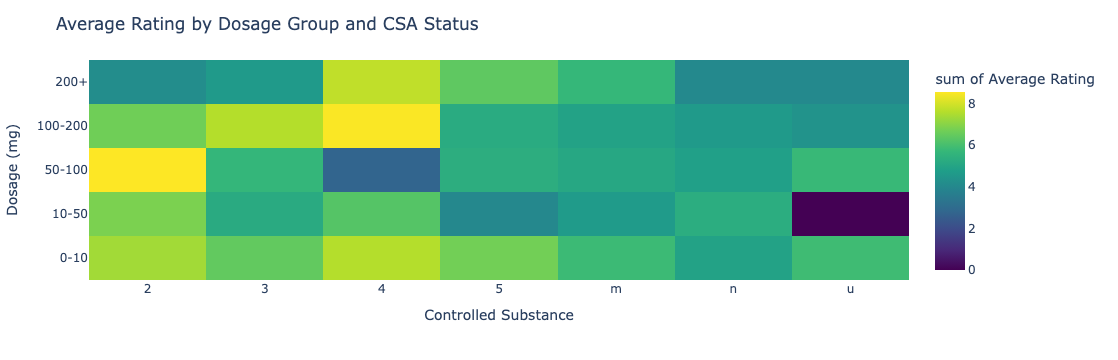

In [289]:
import plotly.express as px

# create pivot table for heatmap
dosage_csa_pivot = dosage_csa_group.pivot(index='dosage_group', columns='csa', values='rating')

# convert the pivot to a long format for Plotly
dosage_csa_pivot_long = dosage_csa_pivot.reset_index().melt(id_vars='dosage_group', var_name='CSA', value_name='Average Rating')

fig = px.density_heatmap(
    dosage_csa_pivot_long, 
    x='CSA', 
    y='dosage_group', 
    z='Average Rating',
    color_continuous_scale='Viridis', 
    labels={'dosage_group': 'Dosage (mg)', 'CSA': 'Controlled Substance', 'Average Rating': 'Average Rating'}
)

fig.update_layout(title='Average Rating by Dosage Group and CSA Status')
fig.show()

- m: Multiple schedules depending on dosage form or strength.
- u: CSA Schedule is unknown.
- n: Not subject to the Controlled Substances Act.
- 1: High potential for abuse, no accepted medical use.
- 2: High potential for abuse, accepted medical use with severe restrictions.
- 3: Moderate potential for abuse, accepted medical use.
- 4: Low potential for abuse, accepted medical use.
- 5: Low potential for abuse relative to Schedule 4, accepted medical use.

#### This heatmap allows us to observe the positive impact of CSA rules on the drugs which limit it for higher dosage abuse. In the heatmap, the CSA with rule 2 and 4 show higher ratings when low dosage but as dosage increases the rating lowers, indicating that CSA rules succesfully impacts in reducing drug abuse. But in case of class 'm' , 'n' and 'u' show very low ratings in all cases indicating the CSA regulations are mapped properly by the government such that which are not CSA regulated doesn't show drug abuse.

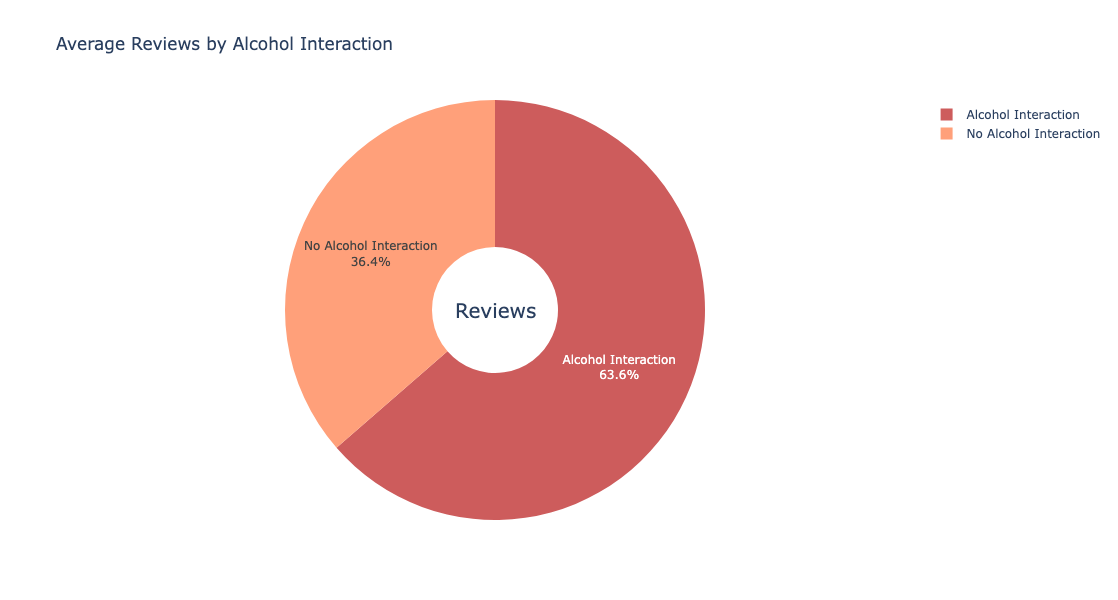

/var/folders/44/9qj8h9610f9cpmlbsc64dspw0000gn/T/ipykernel_35980/2983836136.py:34: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



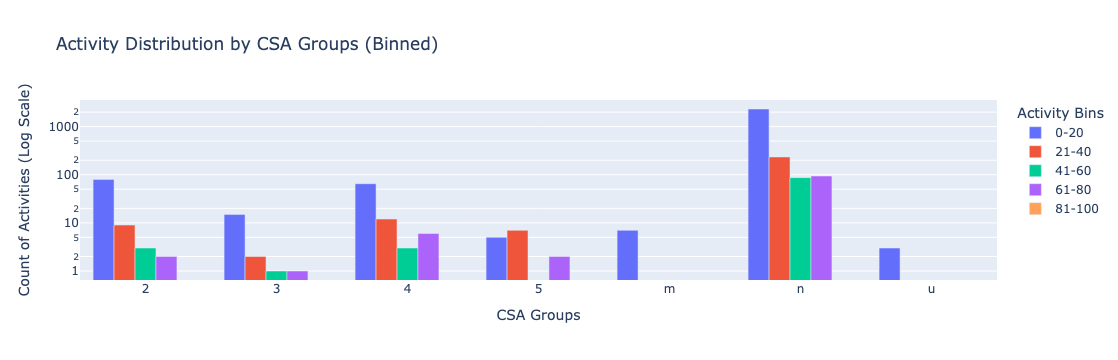

In [304]:
import plotly.graph_objects as go

# summarize the alcohol interactions and average reviews
alcohol_summary = dosage_csa_group.groupby('alcohol_encoded').agg({
    'review': 'mean'
}).reset_index()

# map the alcohol interaction to meaningful labels
alcohol_summary['alcohol_label'] = alcohol_summary['alcohol_encoded'].map({0: 'No Alcohol Interaction', 1: 'Alcohol Interaction'})

fig1 = go.Figure(data=[go.Pie(
    labels=alcohol_summary['alcohol_label'],
    values=alcohol_summary['review'],
    hole=.3,  # Makes it a donut chart
    marker=dict(colors=['lightsalmon', 'indianred']),
    textinfo='label+percent'  # Show label and percentage
)])

fig1.update_layout(
    title='Average Reviews by Alcohol Interaction',
    annotations=[dict(text='Reviews', x=0.5, y=0.5, font_size=20, showarrow=False)],
    width=600,  
    height=600  
)

fig1.show()

# create bins for activity
bins = [0, 20, 40, 60, 80, 100]  
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
df3['activity_binned'] = pd.cut(df3['activity'], bins=bins, labels=labels, right=True)

# summarize the activity counts by CSA groups and binned activity
activity_csa_summary = df3.groupby(['activity_binned', 'csa']).size().reset_index(name='count')


fig2 = go.Figure()

# add a bar for each activity bin
for bin_label in activity_csa_summary['activity_binned'].unique():
    subset = activity_csa_summary[activity_csa_summary['activity_binned'] == bin_label]
    fig2.add_trace(go.Bar(
        x=subset['csa'],          
        y=subset['count'],       
        name=bin_label,           
        hoverinfo='x+y',          
    ))

fig2.update_layout(
    title='Activity Distribution by CSA Groups (Binned)',
    xaxis_title='CSA Groups',
    yaxis_title='Count of Activities (Log Scale)',
    yaxis_type='log',          
    barmode='group',           
    legend_title='Activity Bins',                
)

# show the figure
fig2.show()

#### The bar graph above shows a much wider view on the non-CSA category regulation which is 'n', giving insight on previous assumption that though people are not overdosing the 'n' class drugs but this class has higher activity towards its pages, indicating people tend to search for non-CSA regulated drugs for abuse. Thus, the regulated drugs show lesser activity whereas the non-regulated drugs is shown high interest. 

#### The pie chart implies drugs having alcohol interaction are more reviwed than the no interaction ones. One hypothesis found is there could be adverse effect when the person is drunk and consumes the alcohol interactive drugs, indicating that people who abuse drugs out of the whole population are tend to use this interaction for getting high or the normal people finding the drugs to not work when they previously consumed alcohol implying complaining or giving more reviews.

## Outcome:

#### Hence, we come to a conclusion that CSA regulated drugs are doing a good job to prevent drug abuse but people are still trying to find ways by abusing the 'n' class of CSA or non-regulated drugs. Also, people with previous alcohol consumption find the drug ineffective or the drug abusers use it to get still more high.

## Results : 
#### Therefore, after the EDA we understood the drug abusivness and alcohol interaction on drugs which helps us to model our drug prescription by not recommending 'n' class CSA drugs when dosage is high preventing and helping in the CSA government motive and stopping drug abuse. Also, we can recommend the drugs which are non-interactive with drugs for people thus, reducing the adverse effect and abuse or try adding a query to our app for asking before hand if they have previously consumed alcohol, making it easier for drug prescription.

### Q2) Drugs that are marketed under multiple brand names tend to receive a lower total number of reviews compared to those marketed under a single brand name.

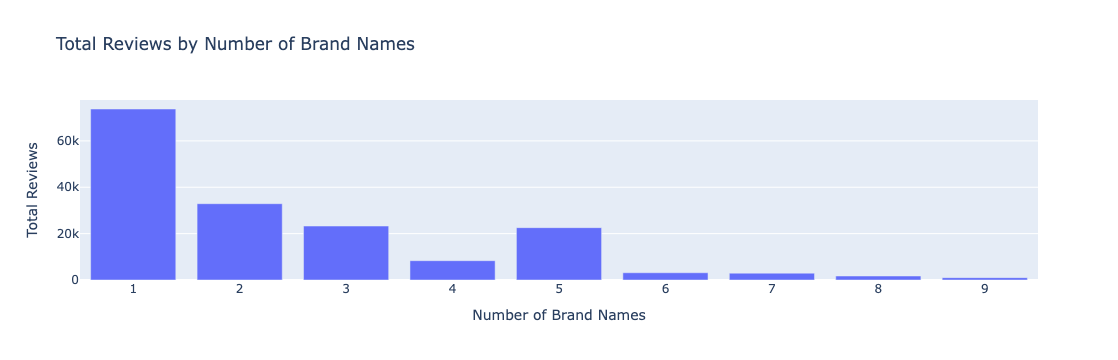

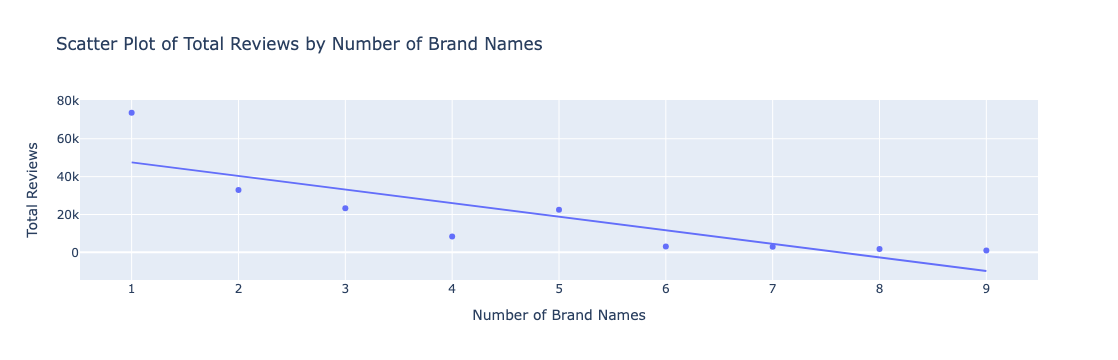

In [360]:
# count the number of unique brand names
df3['brand_names_no'] = df3['brand_name'].apply(lambda x: len(set(x.split('; '))))

# group by the number of brand names and calculate the total number of reviews
review_analysis = df.groupby('brand_names_no').agg({
    'review': 'sum',  
}).reset_index()

# renaming columns for clarity
review_analysis.rename(columns={'review': 'total_reviews'}, inplace=True)

# plotting the relationship using Plotly
fig = px.bar(review_analysis,
              x='brand_names_no',
              y='total_reviews',
              title='Total Reviews by Number of Brand Names',
              labels={'brand_names_no': 'Number of Brand Names', 'total_reviews': 'Total Reviews'})

fig.show()

# calculate total reviews based on brand names
total_reviews = df3.groupby('brand_names_no')['review'].sum().reset_index()
total_reviews.rename(columns={'review': 'total_reviews'}, inplace=True)

# create the scatter plot with trend line
fig4 = px.scatter(total_reviews,
                 x='brand_names_no',
                 y='total_reviews',
                 title='Scatter Plot of Total Reviews by Number of Brand Names',
                 labels={'brand_names_no': 'Number of Brand Names', 'total_reviews': 'Total Reviews'},
                 trendline='ols')  # adding a trend line

fig4.show()

#### The above bar graph depicts that drugs with single brand_names are much more popular than multi branded drug, indicating that the drugs with a common brand and generic names are much popular than many branded drugs. The plot also has a done linear regression on the data points, confirming the downward trend of reviews when the brand names increases meaning less generic and not widely used.

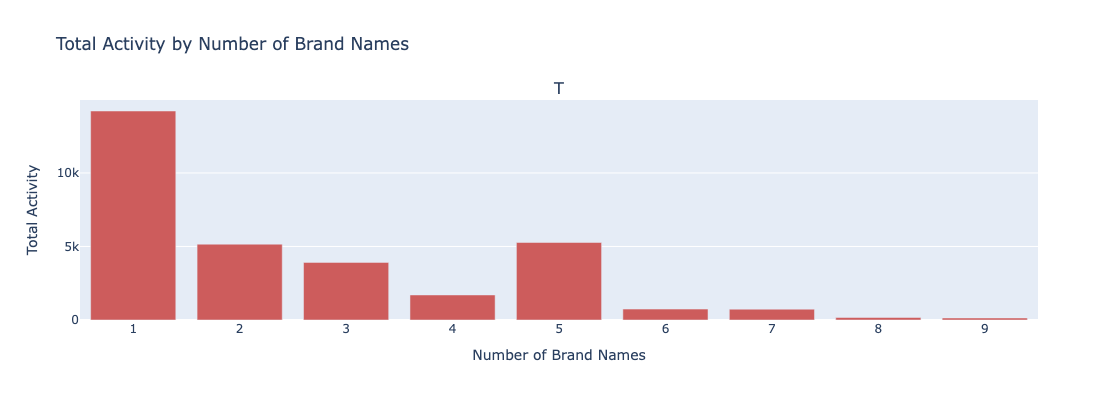

In [358]:
# group by the number of brand names and calculate average rating and sum of activity
review_analysis = df3.groupby('brand_names_no').agg({
    'rating': 'mean',     
    'activity': 'sum'    
}).reset_index()

fig = make_subplots(rows=1, cols=1, subplot_titles=('Total Activity by Number of Brand Names'))

fig.add_trace(go.Bar(
    x=review_analysis['brand_names_no'],
    y=review_analysis['activity'],
    name='Total Activity',
    marker_color='indianred'
), row=1, col=1)

fig.update_layout(
    title='Total Activity by Number of Brand Names',
    xaxis_title='Number of Brand Names',
    yaxis_title='Total Activity',
    height=400  
)

fig.show()

#### In the above graph, it also indicates the same trend as total reviews where the activity on the drugs with single or lesser brand_names, show higher activity compared to higher brand names containing drugs. Thus,confirming our hypothesis.

## Outcome:

#### Hence, we come to a conlusion that brand_names also matter in case of prescription as a ore generic brand is popular than a unknown multi-branded drug. We can calculate this by the high activity and reviews for generic brand whereas for brand_names exceeding 5 are all less popular and less reviewed compared to the generic ones. Also, depicting the hypothesis that the drugs with high activity and reviews are monopolised or in monopoly by huge brands or companies, leading into high control on those popular drugs by a single company.

## Results : 
#### Therefore, after the EDA we understood that when prescribing drugs, we need to look into more generic or lesser brand_names of that particular drug, resulting in better prediction. Also, when prescribing the drug we also have to look into the diseases which have drugs with more generic brands and popular not just by activity being the most used attribute for modeling but also use brand_names for better approach and better performance of the model.

### (Shishir)
### Q3) Is there a significant correlation between the dosage of drugs given for pain and their effectiveness in treating the pain?

The above question is important to understand the optimal dosage of drugs given for pain. If a correlation exists, then we can prove that adjusting the dosage can improve the treatment outcomes. Identifying such a correlation could also contribute to developing more effective treatment strategies and possibly even personalized medicine approaches. By investigating this relationship, researchers can gain valuable insights into the underlying mechanisms of how pain works and develop medicines of suitable dosages. This is a suitable question as medicines for treating pain are coming out in different dosages, therefore it is necessary to find a single optimum dosage.

#### Hypothesis: There is no correlation between the dosage of drugs given for pain and their effectiveness in treating it.

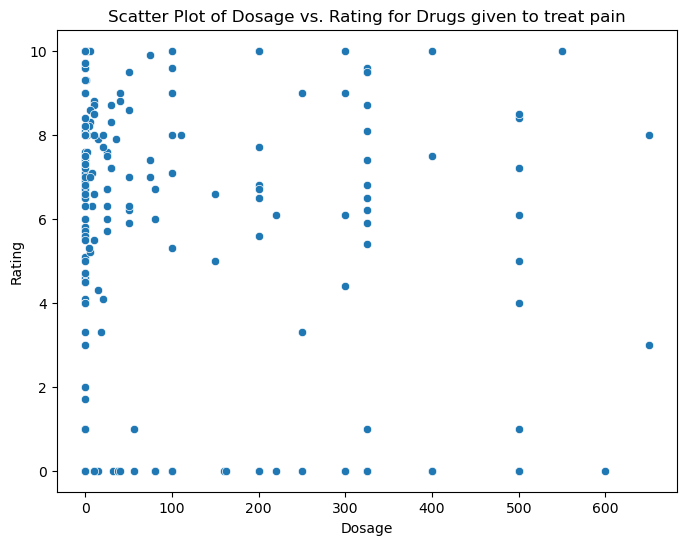

In [409]:
pain_data = df3[df3['disease_list_cleaned'] == 'pain'] # I filter out other rows and keep only the rows with pain as the disease
plt.figure(figsize=(8, 6))
sns.scatterplot(x='dosage_mg', y='rating', data=pain_data) # I create a scatter plot of dosage vs rating
plt.title('Scatter Plot of Dosage vs. Rating for Drugs given to treat pain')
plt.xlabel('Dosage')
plt.ylabel('Rating')
plt.show()


#### Outcomes and results:
Lack of Clear Correlation: The data points are widely scattered, with no obvious linear correlation between dosage and rating. Higher dosages do not appear to lead to consistently higher ratings, and in fact, many low-dosage drugs have high ratings while some higher dosages correspond to lower ratings.

Cluster of Data at Lower Dosages: A large number of data points are concentrated around lower dosages - below 100 mg, with a wide range of ratings (from 0 to 10). This could indicate that the majority of pain medications are administered at lower dosages, but their effectiveness varies widely among patients. However, some ratings are relatively low for these dosages too. Hence we cannot conclude that since most drugs are administered at lower dosages, they are more effective. 

Outliers: There are a few outliers where the dosage is significantly higher - above 500 mg, but the ratings remain low. This suggests that increasing the dosage beyond a certain point may not enhance drug effectiveness and could even be detrimental. In the above graph, as the dosage increases and crosses 300mg, the number of higher ratings are also decreasing.

#### How to Use This Information:
Drop the Dosage as a Standalone Feature: Based on the lack of clear correlation, dosage might not be a strong predictor of effectiveness (rating). While dosage could still be an important feature when combined with other variables, it may not be useful on its own. Therefore, it can be deprioritized in future models.
Since dosage doesn't explain the variation in ratings well, it would be useful to focus on other features.

We can further use this information to agree with the hypothesis. This graph has clearly shown that there is no clear correlation/relationship between dosage and rating. Here we assumed that effectiveness is proportional to ratings as people would rate the drug higher if it was more effective.

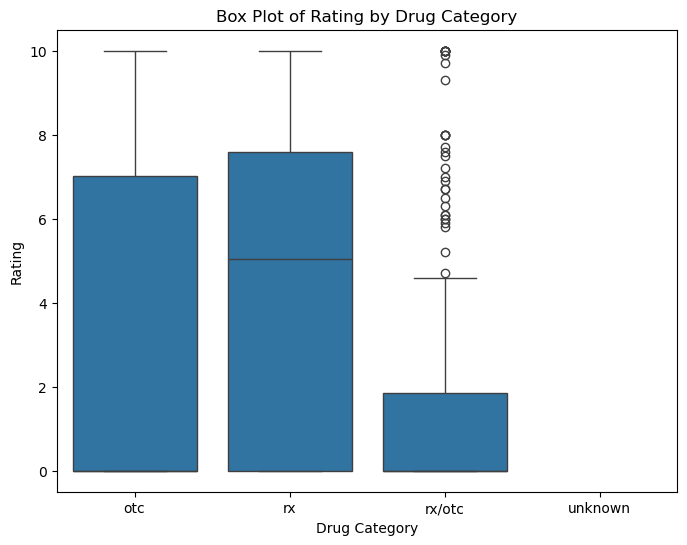

In [414]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='prescription', y='rating', data=pain_data) # Here I am ploting a boxplot of rating by drug category
plt.title('Box Plot of Rating by Drug Category')
plt.xlabel('Drug Category')
plt.ylabel('Rating')
plt.show()

### Outcomes and results:

Drug Category Comparison: 
OTC (Over-the-Counter): Shows a wide range of ratings, with a median rating around 6-7. The distribution appears symmetric. <br>
RX (Prescription): Has a similar range to OTC but slightly more spread out. The median rating is also around 6-7. <br>
RX/OTC (Combination): Shows much lower ratings, with a median closer to 2. The box plot also shows many outliers above the box, indicating a wide variation in effectiveness across users. <br>
Unknown: These are drugs that had null values, hence are very less in number too. We ignore this for the hypothesis

Effectiveness Distribution:
The drugs classified as rx/otc have significantly lower median ratings, suggesting that this category is generally considered less effective because  there is more dissatisfaction with these drugs. <br>
Both otc and rx categories have almost similar ratings, with the middle 50% of the data lying between 4 and 8.

#### How to use this information:
Could further categorize by dosage: Using a more granular box plot that incorporates dosage (low, medium, high) within each drug category could help in understanding the optimal dosage for effectiveness.

In the above graph, we can see that otc and rx drugs are quite similar in their ratings. It is known that drugs with higher ratings are generally rx prescribed as a doctor needs to approve them. However since otc and rx drugs have a similar median, we can indirectly say that the drugs with higher dosages and lower dosages have a similar rating. Since we have assumed that rating is proportional to the effectiveness of the drug, we conclude that the above hypothesis holds and there is no correlation between drug dosage and rating.

### Q4) How does the frequency of a drug's prescription relate to its perceived effectiveness (rating)?
This question is crucial because it tries to uncover whether a drug's prescription frequency indicates its effectiveness in treating diseases, as perceived by healthcare providers. A positive correlation between prescription frequency and drug ratings would suggest that frequently prescribed drugs are more effective, which aligns with identifying optimal treatment options. If no such relationship exists, it indicates that factors other than prescription frequency play a more significant role in patient satisfaction. We try to identify the relationship between a particular drug's prescription frequency and the rating. This could give insights to medical providers as to which drug is more effective and how it should be prescribed.

#### Hypothesis: Drugs with higher prescription frequency are more likely to have higher ratings.


/var/folders/44/9qj8h9610f9cpmlbsc64dspw0000gn/T/ipykernel_35980/3306529406.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



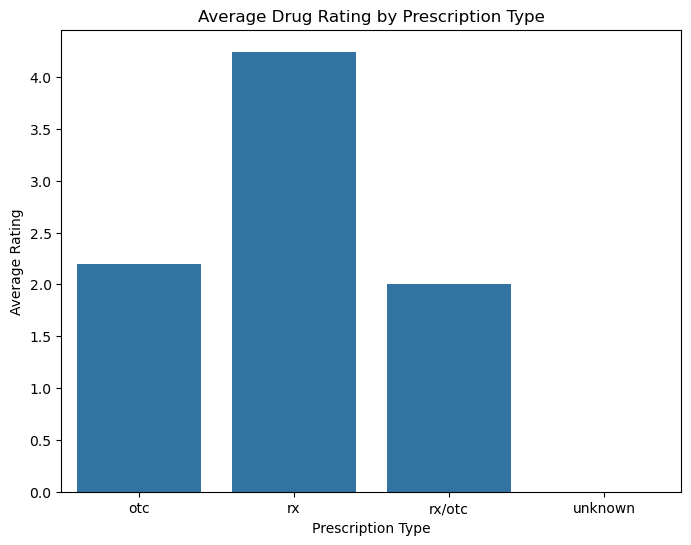

In [422]:
df4 = df3
prescription_freq = df4['prescription'].value_counts().reset_index() # Here I am finding the prescription frequency for all the drugs
prescription_freq.columns = ['prescription', 'frequency']
df4 = df4.merge(prescription_freq, on='prescription') # I merge the frequency back to the main dataframe
avg_rating_by_prescription = df4.groupby('prescription')['rating'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(x='prescription', y='rating', data=avg_rating_by_prescription) # Here I am plotting the bar plot of prescription frequency vs rating
plt.title('Average Drug Rating by Prescription Type')
plt.xlabel('Prescription Type')
plt.ylabel('Average Rating')
plt.show()

#### Outcomes and results:
The rx (prescription-only) drugs have the highest average rating - above 4, suggesting that these drugs are seen as the most effective. <br>
The otc (over-the-counter) drugs have an average rating slightly above 2, suggesting lower perceived effectiveness compared to rx drugs.<br>
The rx/otc combination has a rating slightly above 2.5, suggesting that these are not as effective as the other 2 categories.<be>

Therefore, drugs that require a prescription (rx) have higher ratings, implying a perceived effectiveness. This could be because prescription drugs are often stronger and tailored for specific conditions, which might lead to better results compared to over-the-counter alternatives.

#### How to use this information:
Further investigation: To further validate the hypothesis, I can investigate whether the frequency of prescriptions has a relationship with ratings to identify if certain drugs are prescribed more often due to their effectiveness.

It is seen that the drugs that need a prescription (rx) have a higher rating, this indicates that the hypothesis is true.

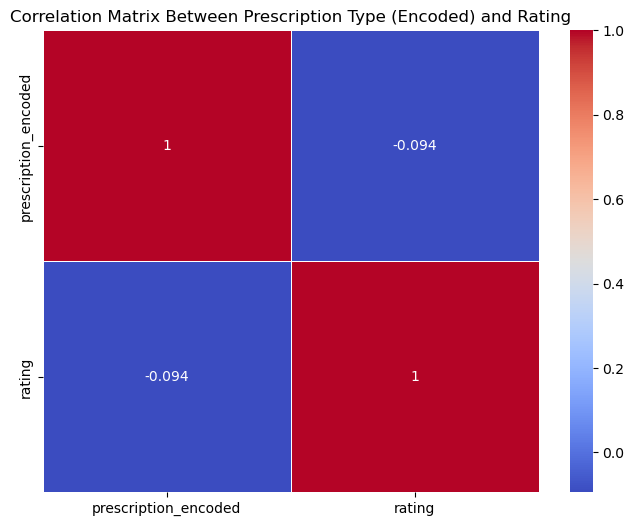

In [425]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df4['prescription_encoded'] = label_encoder.fit_transform(df4['prescription'])
correlation_matrix = df4[['prescription_encoded', 'rating']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Between Prescription Type (Encoded) and Rating')
plt.show()

### Outcomes and results:

Correlation Result: The correlation coefficient between prescription_encoded (which is the encoded prescription type) and rating is -0.094, indicating a very weak negative correlation. This suggests that there is almost no meaningful linear relationship between how often a drug is prescribed (in terms of its type) and its effectiveness as perceived through ratings.

Visual Representation: The heatmap visually confirms this outcome, showing nearly no correlation between prescription_encoded and rating. The values are close to zero, meaning that changes in prescription type are not associated with proportional changes in rating.

The weak negative correlation (near zero) suggests that the frequency of a drug’s prescription does not strongly relate to its perceived effectiveness. This result contradicts the initial hypothesis, which predicted a positive relationship between prescription frequency and drug ratings.

The insight here is that prescription frequency alone may not be a reliable indicator of a drug’s effectiveness as perceived by healthcare providers or patients. Other factors, such as the specific nature of the illness being treated, the drug’s side effects, cost, accessibility, and patient demographics, might be influencing the ratings more significantly than the frequency of prescriptions. Therefore proves the hypothesis.

#### How to use this information:
The weak negative correlation (near zero) suggests that the frequency of a drug’s prescription does not strongly relate to its perceived effectiveness. This result contradicts the initial hypothesis, which predicted a positive relationship between prescription frequency and drug ratings.

The insight here is that prescription frequency alone may not be a reliable indicator of a drug’s effectiveness as perceived by healthcare providers or patients. Other factors, such as the specific nature of the illness being treated, the drug’s side effects, cost, accessibility, and patient demographics, might be influencing the ratings more significantly than the frequency of prescriptions.

## (Jahnavi)
### Q5) How do specific symptoms (e.g., fever, cough, difficulty breathing) combined with health indicators (e.g., blood pressure, cholesterol level) affect the likelihood of patients being diagnosed with severe respiratory conditions such as asthma or influenza?

This question aims to investigate whether the combination of common symptoms and critical health indicators can help predict the presence and severity of respiratory conditions, providing insight into how these features interact in the context of disease diagnosis.

### HYPOTHESIS:
Patients with certain symptoms (e.g., fever, cough, difficulty breathing) and health indicators (e.g., blood pressure, cholesterol level) are more likely to have severe respiratory conditions like asthma or influenza.


In [438]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = pd.read_csv('symptoms.csv')

symptoms = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing']

data[symptoms] = data[symptoms].replace({'Yes': 1, 'No': 0})

symptom_prevalence = data.groupby('Disease')[symptoms].mean() * 100

print("Symptom Prevalence by Disease (%):")
print(symptom_prevalence)

Symptom Prevalence by Disease (%):
                                   Fever       Cough     Fatigue  \
Disease                                                            
ADHD                           55.813953   44.186047   67.441860   
AIDS/HIV                       70.833333   41.666667   37.500000   
Acne                           50.000000   42.500000   55.000000   
Allergic Rhinitis              33.333333   66.666667   66.666667   
Allergies                      40.476190   54.761905   47.619048   
...                                  ...         ...         ...   
Urinary Incontinence           37.500000   50.000000   57.500000   
Urinary Tract Infection        60.000000   60.000000   60.000000   
Urinary Tract Infection (UTI)  66.666667   33.333333   66.666667   
Williams Syndrome               0.000000    0.000000  100.000000   
Zika Virus                      0.000000  100.000000  100.000000   

                               Difficulty Breathing  
Disease                   

/var/folders/44/9qj8h9610f9cpmlbsc64dspw0000gn/T/ipykernel_35980/1863028801.py:9: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



The table shows the percentage of patients with each symptom for every disease. Respiratory conditions like asthma and influenza are expected to show higher percentages of patients with cough, fever, and difficulty breathing. This helps us understand which symptoms are highly predictive of respiratory conditions. Symptoms with high prevalence in respiratory diseases will be considered important features for predicting respiratory diseases.

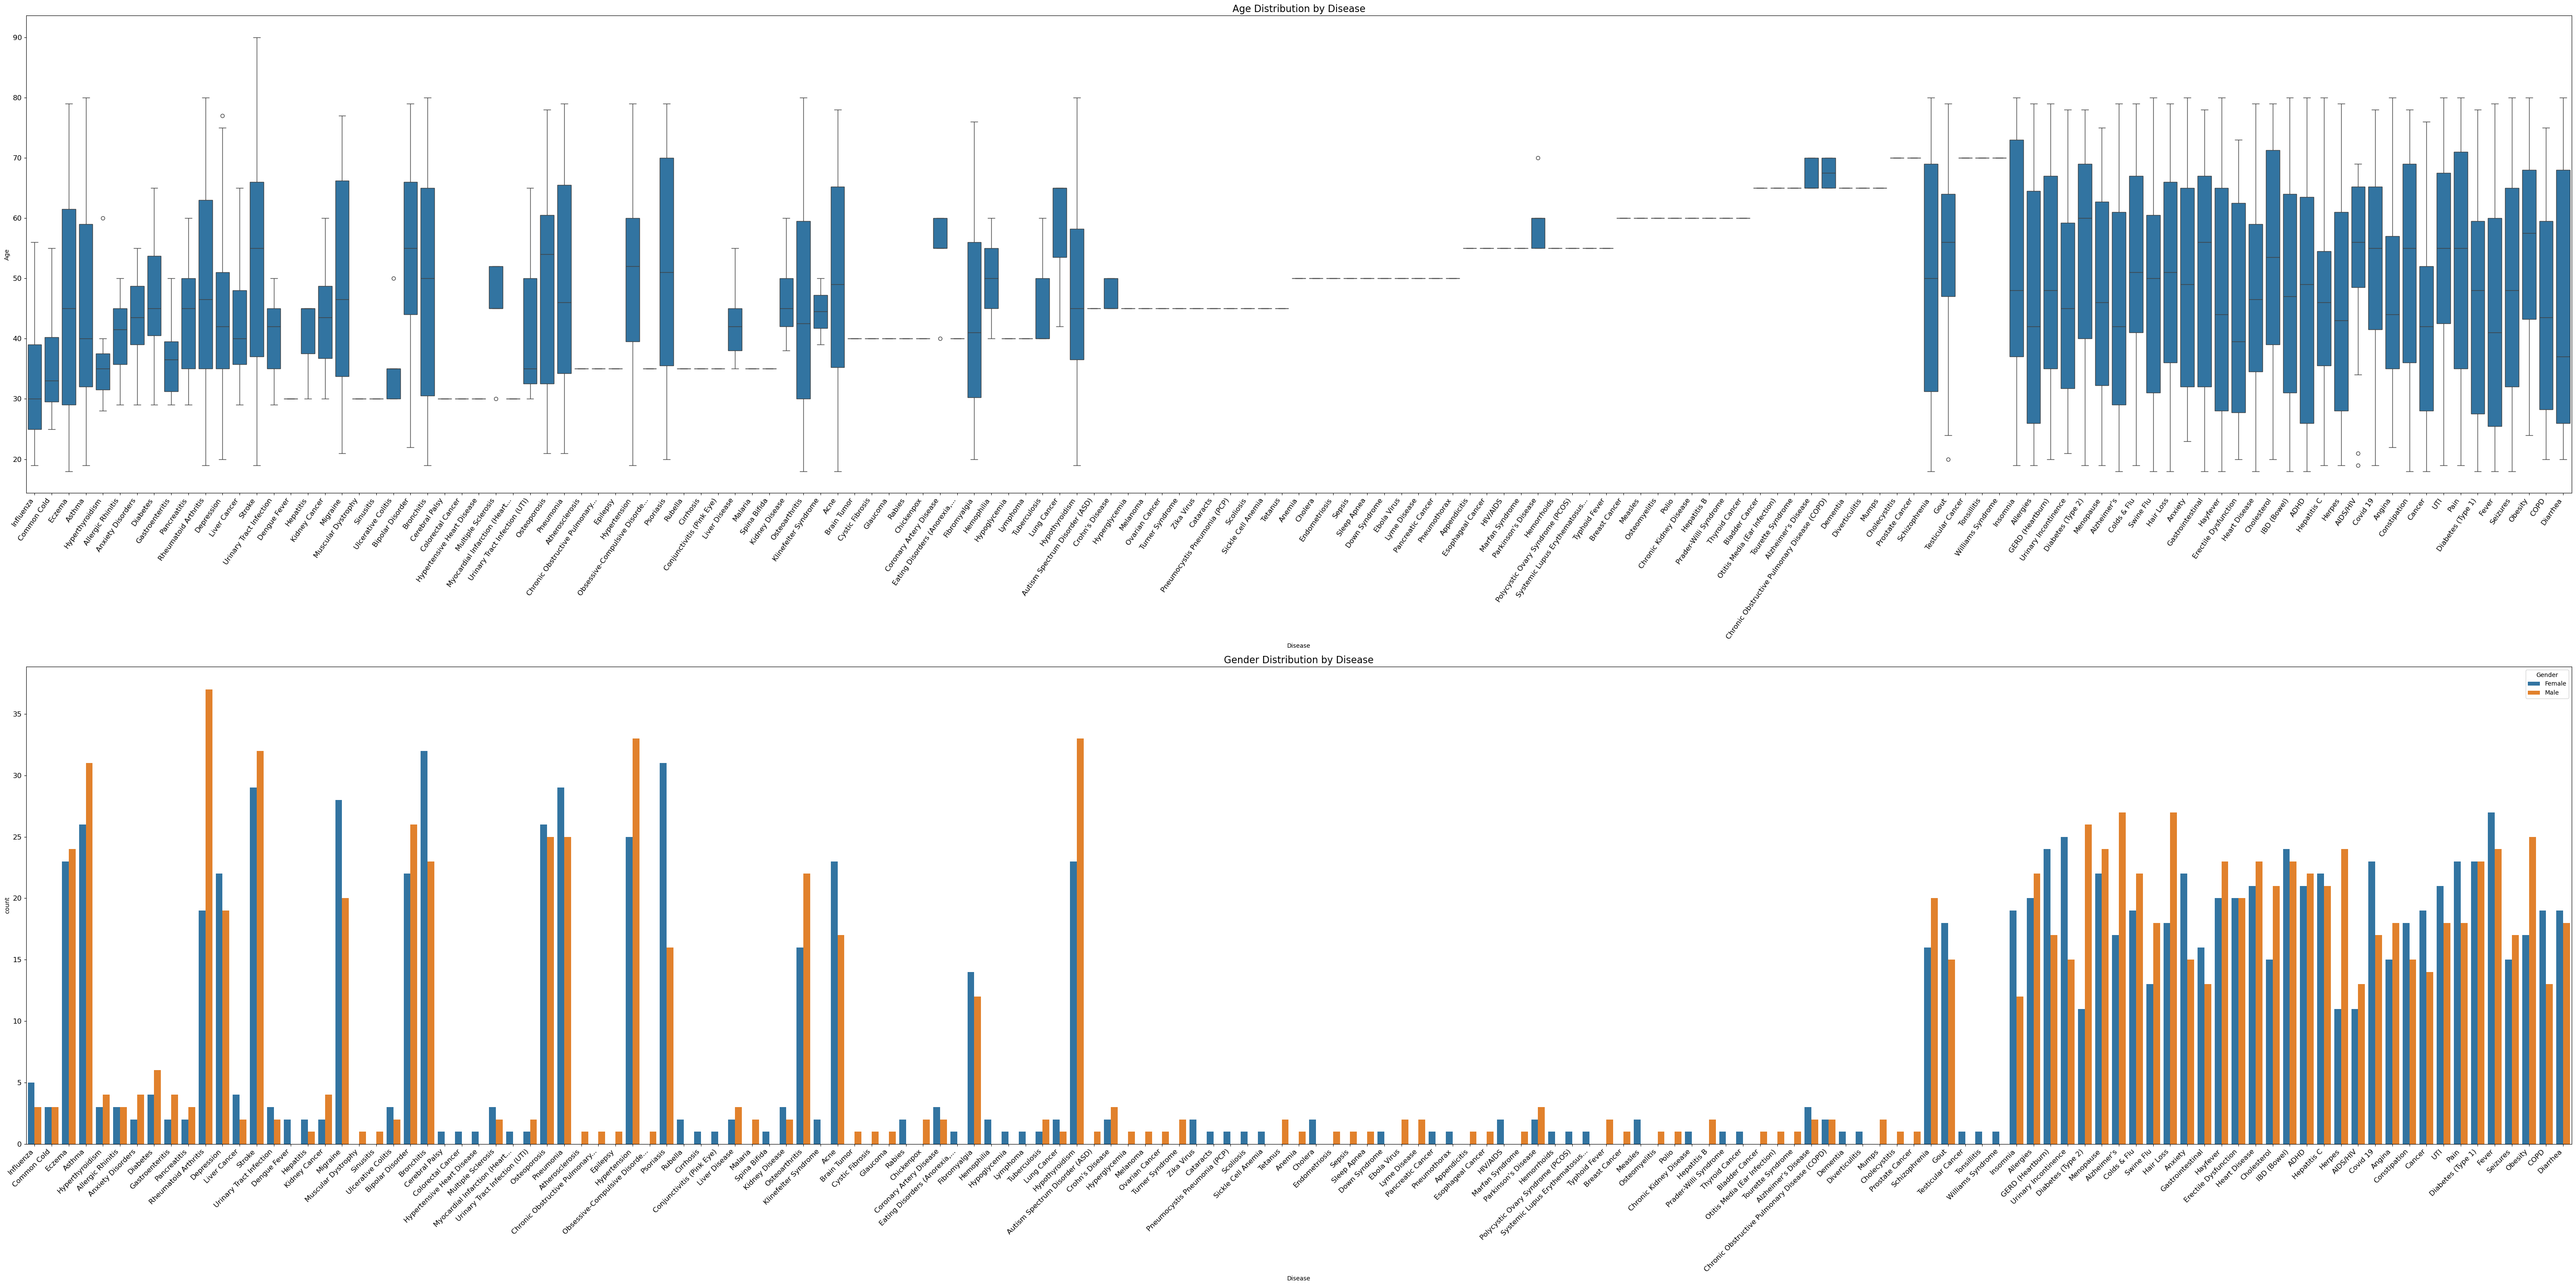

In [440]:
plt.figure(figsize=(60, 30))

# Age distribution
plt.subplot(2, 1, 1)
sns.boxplot(x='Disease', y='Age', data=data)
plt.title('Age Distribution by Disease', fontsize=16)
plt.xticks(rotation=55, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Gender distribution
plt.subplot(2, 1, 2)
sns.countplot(x='Disease', hue='Gender', data=data)
plt.title('Gender Distribution by Disease', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.subplots_adjust(wspace=0.4, hspace=0.4)

plt.tight_layout()
plt.show()

### OUTCOMES AND RESULTS:

The first plot shows how the age distribution varies between diseases. The prevalence of some diseases may vary among young and old people. A boxplot shows the age distribution of diseases, highlighting how the ailment affects people of all ages. For chronic conditions such as hypertension or diabetes, the boxplot may show a higher prevalence among older patients, with the median age tilted upward. Alternatively, asthma or viral disorders may have a wider age distribution, perhaps favoring the younger population.

The gender distribution bar plot (second plot) shows the gender ratio for each ailment, which helps us determine whether particular conditions affect one gender more than the other. The bar plot depicts the gender distribution for each ailment, indicating whether particular conditions are more common in men or women. Respiratory diseases such as asthma or influenza may have a balanced or slightly distorted distribution, whereas cardiovascular disorders may have a clear gender bias, potentially harming men more than women.

Age and gender are likely to be strong predictors for certain diseases and will guide feature selection.


### Q6) Are older age groups more likely to have higher cholesterol levels compared to younger age groups?

This question explores whether there is a significant correlation between age and cholesterol levels, with the assumption that older individuals might have a higher likelihood of elevated cholesterol, which can influence the prevalence of related health conditions. The outcome could help in assessing risk factors based on age and cholesterol levels.

### HYPOTHESIS:
Higher age groups are more likely to have higher cholesterol levels and related diagnoses, such as heart disease.

/var/folders/44/9qj8h9610f9cpmlbsc64dspw0000gn/T/ipykernel_35980/1404681422.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



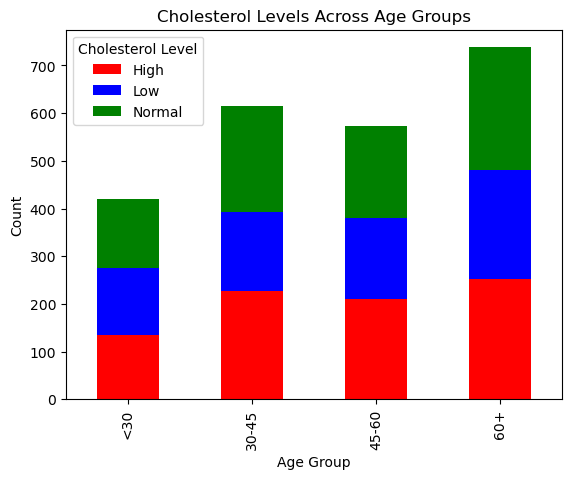

In [442]:
# Create age categories
age_bins = [0, 30, 45, 60, 100]
age_labels = ['<30', '30-45', '45-60', '60+']
data['Age Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=False)

# Check the relationship between age groups and cholesterol levels
age_cholesterol_count = data.groupby(['Age Group', 'Cholesterol Level']).size().unstack()

# Display the result
age_cholesterol_count

# Plot the cholesterol levels by age group
age_cholesterol_count.plot(kind='bar', stacked=True, color=['red', 'blue', 'green'])

plt.title('Cholesterol Levels Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Cholesterol Level')
plt.show()


### OUTCOMES AND RESULTS:

Visualizing the data through a stacked bar plot shows a clear trend where high cholesterol levels become more prevalent as age increases. The less than 30 age group has a minimal percentage of high cholesterol cases, while the 60+ group has a significantly higher count. If higher cholesterol levels are more common in older age groups, this could be an important factor in predicting diseases related to age and lifestyle. This might prompt you to create an interaction feature between age and cholesterol levels for downstream analysis.


### (Ruthvik)
Q7) What is the impact of pregnancy safety categories on the prescription patterns of drugs for women of childbearing age?
-----------------------------------------------------------------------------------------------------------------------
### Hypothesis: 
Drugs with higher pregnancy risk (categorized as B, C, etc.) may be prescribed less frequently to women of childbearing age due to potential risks to fetal health.
### Objective: 
This question seeks to analyze the influence of pregnancy safety categories on prescribing decisions, particularly for women with conditions that may require long-term or critical treatment.
### Significance: 
Pregnancy safety is crucial in medical decision-making for women of reproductive age. Understanding how risk categories affect drug prescriptions can lead to better-informed choices by both doctors and patients, ensuring safer pregnancies and effective treatments.

/var/folders/44/9qj8h9610f9cpmlbsc64dspw0000gn/T/ipykernel_35980/3082951194.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



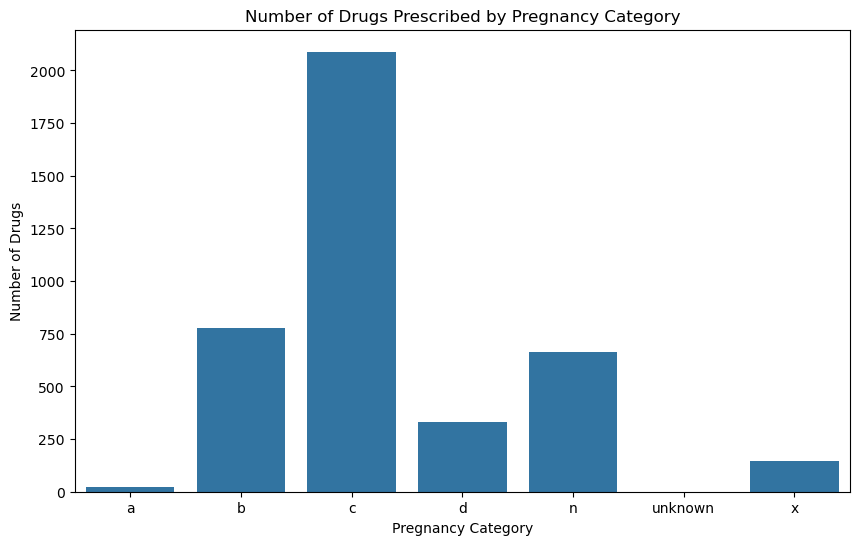

In [389]:
dff = df3
dff = dff[dff['preg'] != 'unknown']
pregnancy_counts = dff.groupby('preg')['drug_name'].count().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=pregnancy_counts, x='preg', y='drug_name')
plt.title('Number of Drugs Prescribed by Pregnancy Category')
plt.xlabel('Pregnancy Category')
plt.ylabel('Number of Drugs')
plt.show()


#### Outcome and Results:
The bar chart shows that **Category C** drugs, which pose moderate risks to fetal health, are prescribed most frequently, contradicting the hypothesis that higher-risk drugs (like B, C, etc.) would be prescribed less often. **Category B** drugs are also prescribed in notable numbers, while **Categories D** and **X** (higher risk) are prescribed less frequently, supporting the hypothesis for these more dangerous drugs. In summary, the data partially disproves the hypothesis since **Category C** drugs are still commonly prescribed despite potential risks, while the riskiest drugs (**D** and **X**) are prescribed less frequently, aligning with the hypothesis.

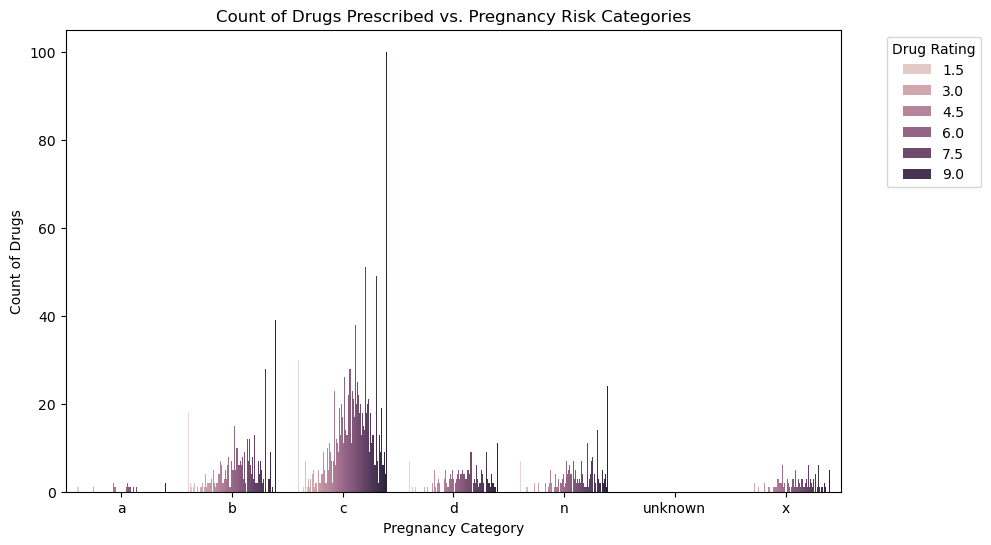

In [376]:
dff = dff[dff['rating'] != 0]
plt.figure(figsize=(10, 6))
sns.countplot(data=dff, x='preg', hue='rating')
plt.title('Count of Drugs Prescribed vs. Pregnancy Risk Categories')
plt.xlabel('Pregnancy Category')
plt.ylabel('Count of Drugs')
plt.legend(title='Drug Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Outcome and Results:
The analysis shows that Pregnancy Categories B and C are prescribed more frequently because a larger number of drugs in these categories have higher ratings. These higher ratings reflect better effectiveness, safety profiles, or clinical reliability, making them preferable options even in the face of moderate pregnancy risks. As a result, the abundance of highly-rated drugs in moderate-risk categories (B and C) leads to higher prescription counts, while high-risk categories like D and X see fewer prescriptions due to both lower ratings and higher perceived risks. 
The hypothesis is **partially disproven**. While it's true that higher-risk drugs (in categories D and X) are prescribed less often, drugs in moderate-risk categories (B and C) are prescribed more frequently because they tend to have higher ratings and are seen as more reliable. This shows that prescription patterns are influenced by both the **risk category** and **drug rating**.

Q8) What is the correlation between drug activity levels (percentage of patients who experience effectiveness) and prescription status (Rx vs. OTC)?
------------------------------------------------------------------------------------------------------------------------------------------------
### Hypothesis: 
Prescription drugs (Rx) may have higher activity levels compared to over-the-counter (OTC) drugs, as they are designed for more specific or severe conditions, often with higher efficacy but potentially more side effects.
### Objective: 
This question aims to explore how the perceived effectiveness of a drug (measured by activity) correlates with its accessibility (Rx vs. OTC), which could shed light on the trade-offs between efficacy and ease of access.
### Significance: 
This is important because it directly relates to healthcare accessibility and treatment outcomes. Investigating whether OTC drugs offer sufficient activity compared to Rx drugs can help assess whether easier access to medications is offset by reduced effectiveness.

/var/folders/44/9qj8h9610f9cpmlbsc64dspw0000gn/T/ipykernel_35980/3576048070.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



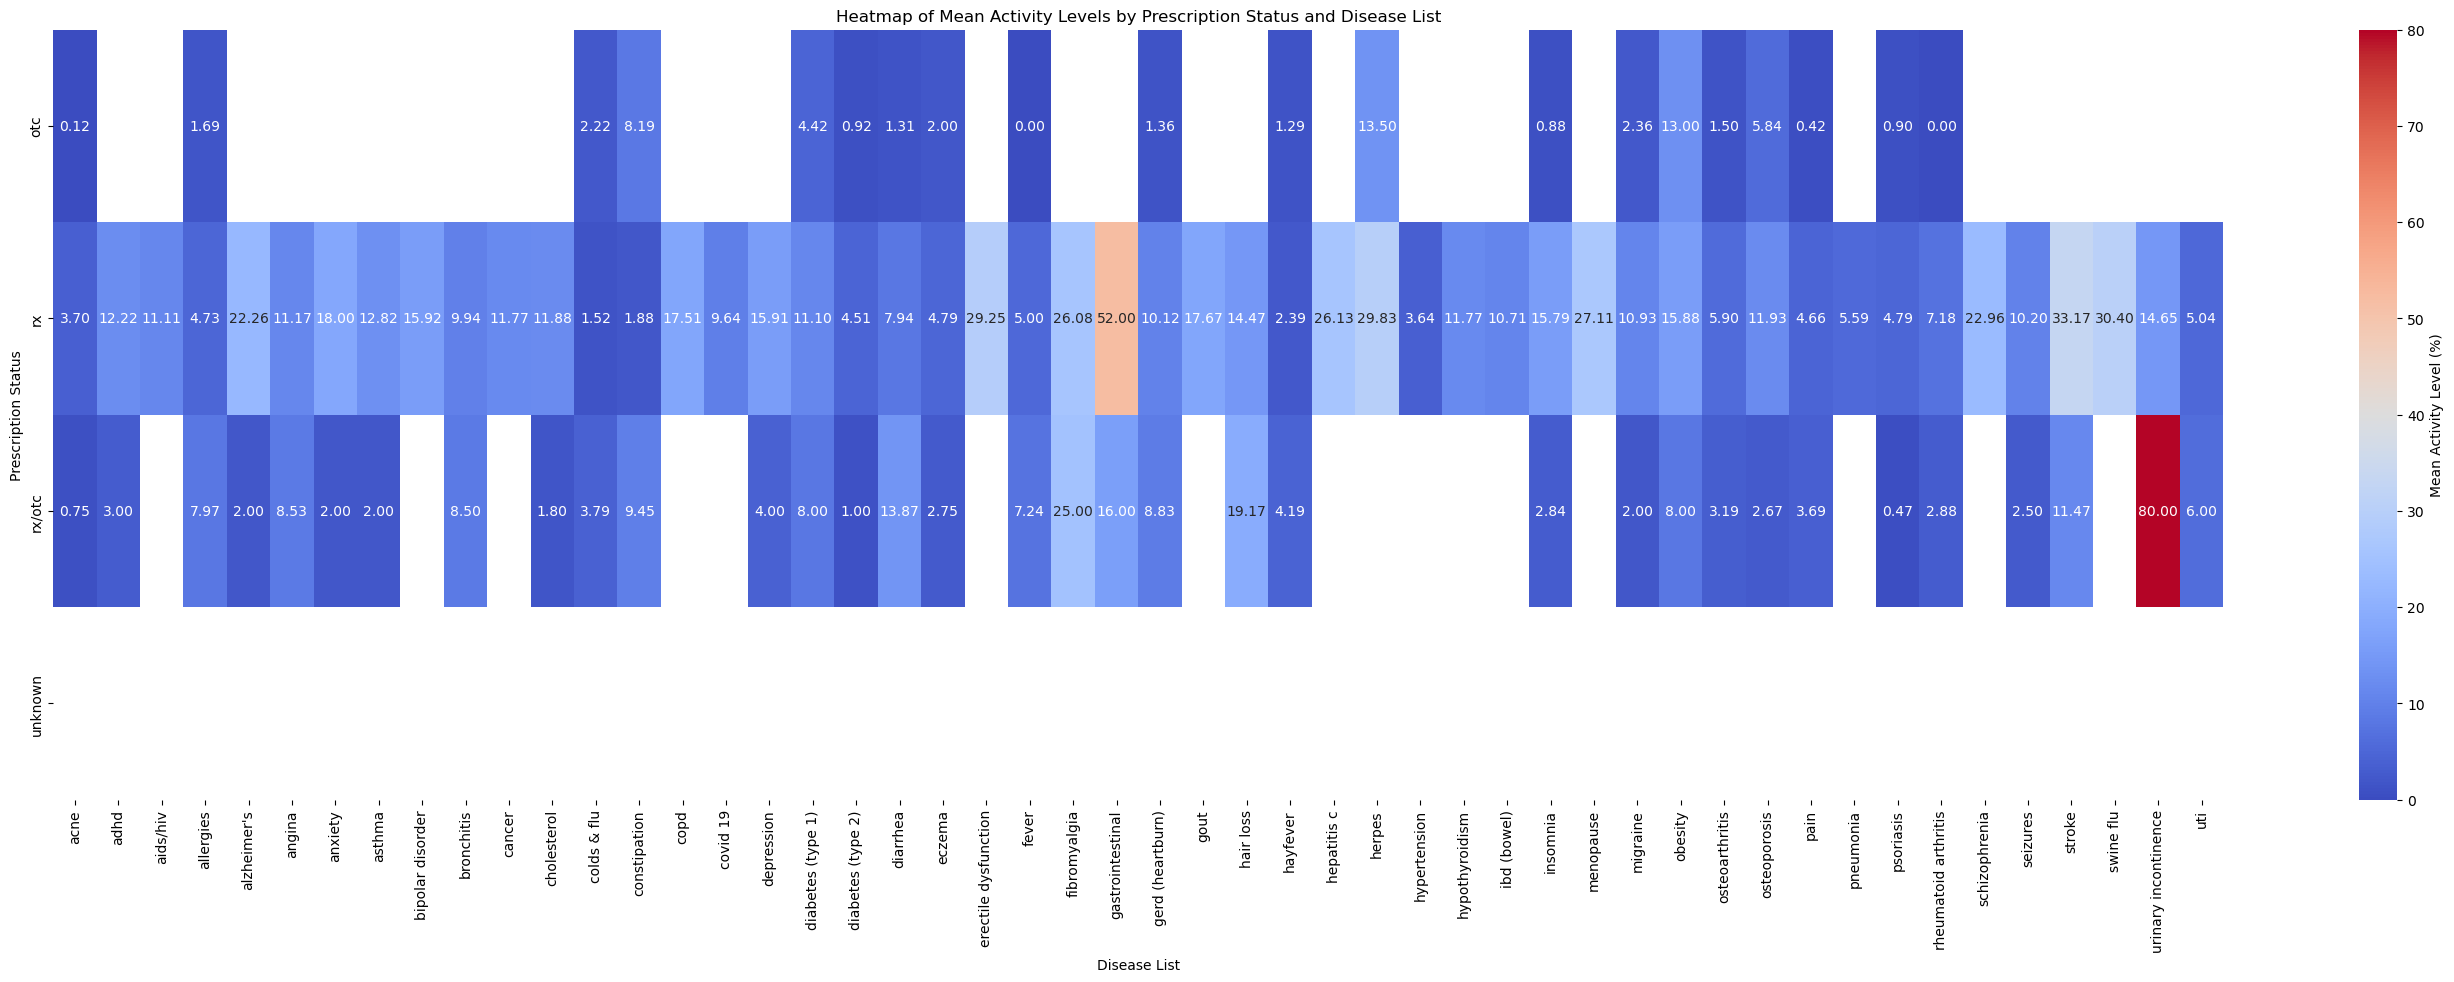

In [393]:
df_clean = df[df['prescription'] != 'unknown']
df_clean = df_clean.dropna(subset=['activity', 'prescription'])

# Convert prescription status to binary (Rx = 1, OTC = 0)
df_clean['prescription_binary'] = df_clean['prescription'].apply(lambda x: 1 if x == 'Rx' else 0)

activity_disease = df_clean.groupby(['prescription', 'disease_list'])['activity'].mean().unstack()
plt.figure(figsize=(35, 10))
sns.heatmap(activity_disease, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Mean Activity Level (%)'})
plt.title('Heatmap of Mean Activity Levels by Prescription Status and Disease List')
plt.xlabel('Disease List')
plt.ylabel('Prescription Status')
plt.show()


#### Outcome and Results:
The heatmap provides a comprehensive overview of mean activity levels across different prescription statuses and various diseases. It highlights that certain conditions, such as Gastrointestinal, show notably high activity levels for prescription medications, suggesting a targeted effectiveness that supports their use in managing more complex health issues. While some diseases also indicate higher activity levels for OTC drugs, the overall trend confirms that Rx medications tend to be more effective for serious health conditions. The visual representation of this data makes it easy to compare the efficacy of different drugs across various diseases, clearly displaying the differences between prescription and OTC drugs. This acts as valuable resource for understanding how specific medications may perform in treating different health conditions, guiding healthcare professionals in their decision making processes.

/var/folders/44/9qj8h9610f9cpmlbsc64dspw0000gn/T/ipykernel_35980/3438957023.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/44/9qj8h9610f9cpmlbsc64dspw0000gn/T/ipykernel_35980/3438957023.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




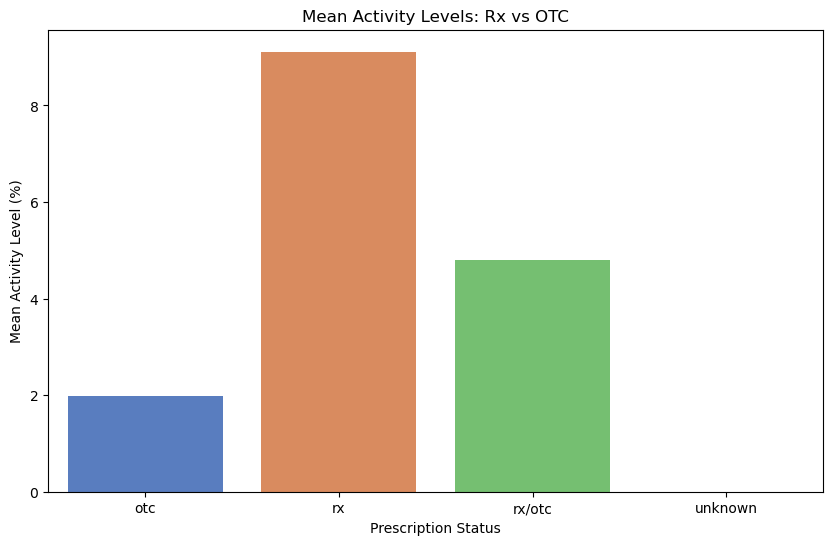

In [398]:
mean_activity = df_clean.groupby('prescription')['activity'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='prescription', y='activity', data=mean_activity, palette='muted')
plt.title('Mean Activity Levels: Rx vs OTC')
plt.xlabel('Prescription Status')
plt.ylabel('Mean Activity Level (%)')
plt.show()

#### Outcome and Results:
The bar chart clearly shows the differences in mean activity levels between prescription (Rx) and over-the-counter (OTC) drugs. Prescription drugs exhibit a significantly higher mean activity level compared to OTC medications, reinforcing the notion that Rx drugs are often designed to treat more serious conditions and typically possess greater efficacy. This finding supports the hypothesis that Rx drugs are more effective for certain medical issues. Also, OTC drugs show much lower activity levels, suggesting they are less potent and intended for milder conditions. The category for combined medications (rx/otc) fall short of the effectiveness observed in prescription medications. This variance highlights the necessity of specific drug classifications and their contexts when evaluating treatment options.

#### How to use this for downstream modeling and analytics?
Based on the insights gained from the bar chart and heatmap. Irrelevant features that do not contribute meaningfully to the analysis can be dropped, streamlining the dataset for improved performance. Any missing values will be addressed through median imputation to maintain data integrity. I can also normalize the activity_level to ensure consistency across input features, and create disease-specific subsets to enhance the accuracy of the models. Finally, split the dataset into training and testing sets, ensuring a representative distribution of drug types and conditions, which will prepare the data effectively for predictive modeling.